# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**
### **Métodos Predictivos**
### Cátedra: Bianco
#### **Regresión Lineal Múltiple**

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import skew

# Ejercicios prácticos con Datos

---

## Publicidad y Ventas

Esta base de datos describe la relación entre la publicidad en TV, radio, newspaper y ventas (`sales`).

In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df_ads = pd.read_csv(url)
df_ads.drop(columns=["Unnamed: 0"], inplace=True)
df_ads.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
df_ads.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


Veamos la relación de cada variable con cada tipo de publicidad. Primero con un mapa de calor según correlación.

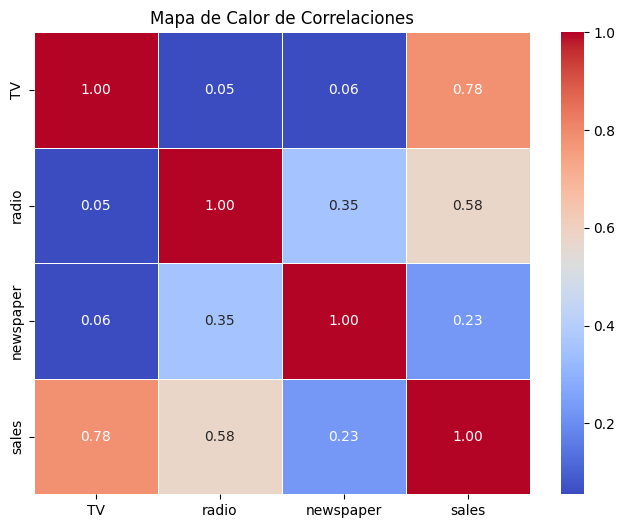

In [4]:
corr_df = df_ads.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5
)
plt.title("Mapa de Calor de Correlaciones")
plt.show()

Ahora veamos visualmente.

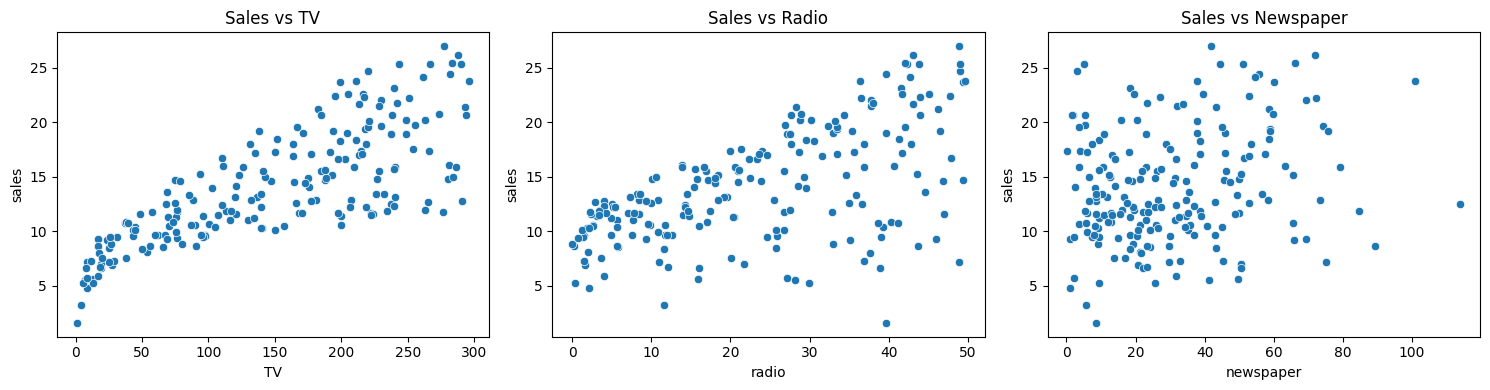

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=df_ads, x="TV", y="sales", ax=axes[0])
axes[0].set_title("Sales vs TV")

sns.scatterplot(data=df_ads, x="radio", y="sales", ax=axes[1])
axes[1].set_title("Sales vs Radio")

sns.scatterplot(data=df_ads, x="newspaper", y="sales", ax=axes[2])
axes[2].set_title("Sales vs Newspaper")

plt.tight_layout()
plt.show()

Otra opción con la regresión simple entre ambas variables.

$$sales = \beta_0 + \beta_1 \cdot TV + \varepsilon$$
$$sales = \beta_0 + \beta_1 \cdot radio + \varepsilon$$
$$sales = \beta_0 + \beta_1 \cdot newspaper + \varepsilon$$

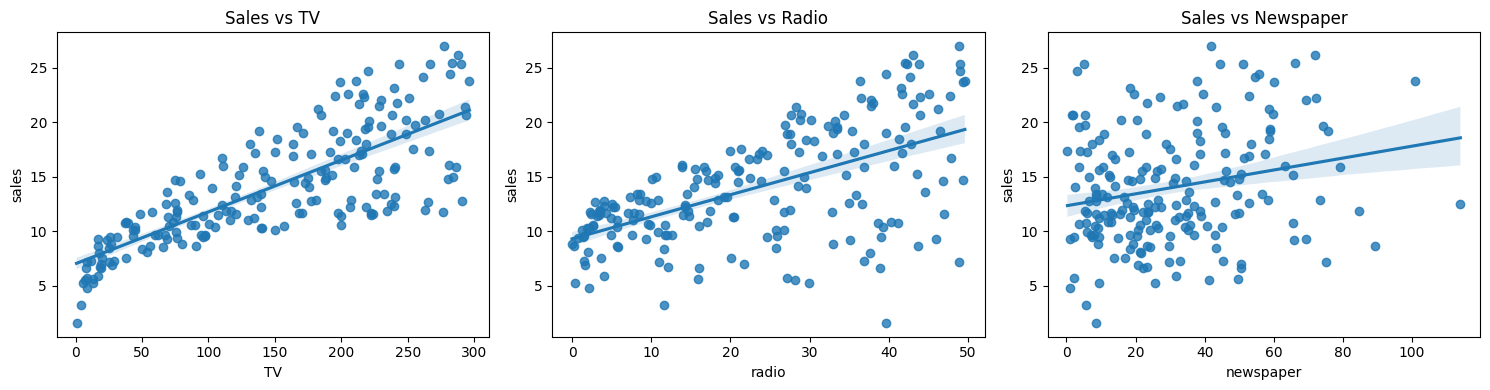

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df2 = df_ads.copy()

sns.regplot(data=df2, x="TV", y="sales", ax=axes[0], ci=90)
axes[0].set_title("Sales vs TV")

sns.regplot(data=df2, x="radio", y="sales", ax=axes[1], ci=90)
axes[1].set_title("Sales vs Radio")

sns.regplot(data=df2, x="newspaper", y="sales", ax=axes[2], ci=90)
axes[2].set_title("Sales vs Newspaper")

plt.tight_layout()
plt.show()

Otra opción.

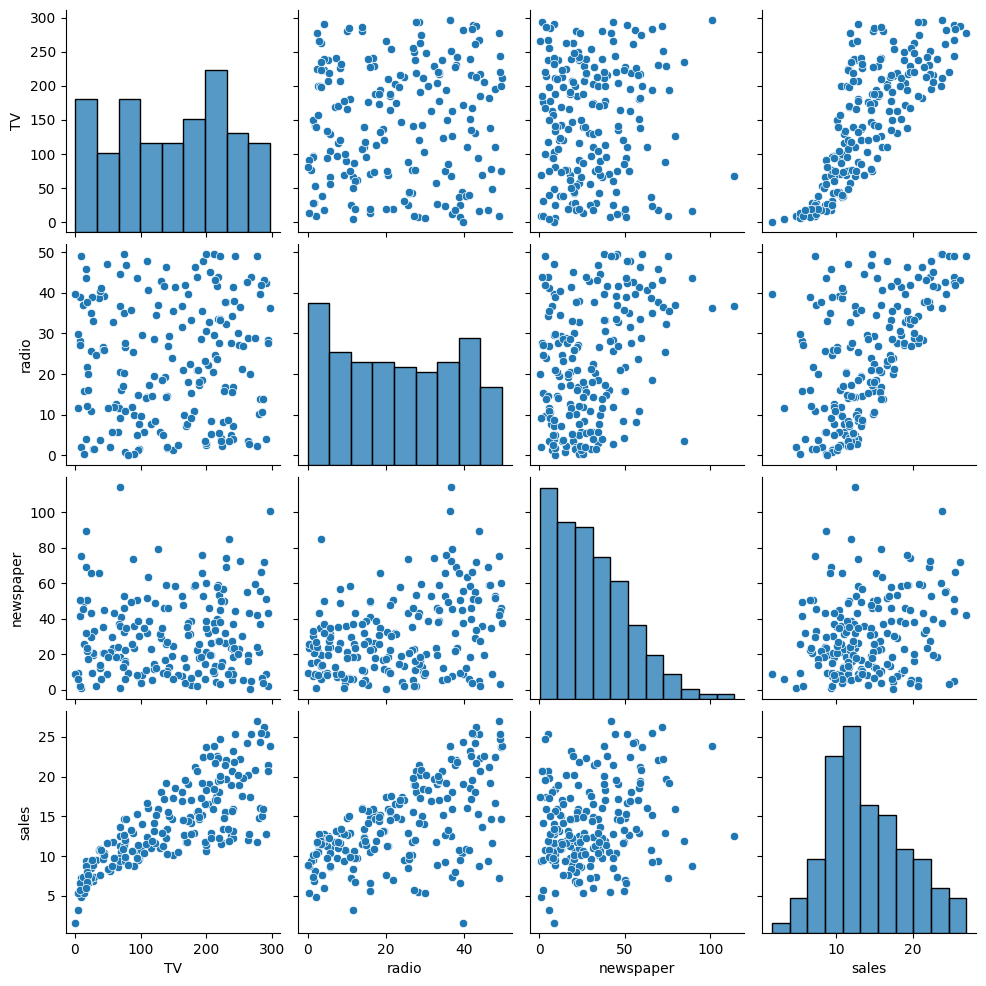

In [7]:
sns.pairplot(df_ads[["TV", "radio", "newspaper", "sales"]])
plt.show()

Lo mismo pero con línea de tendencia.

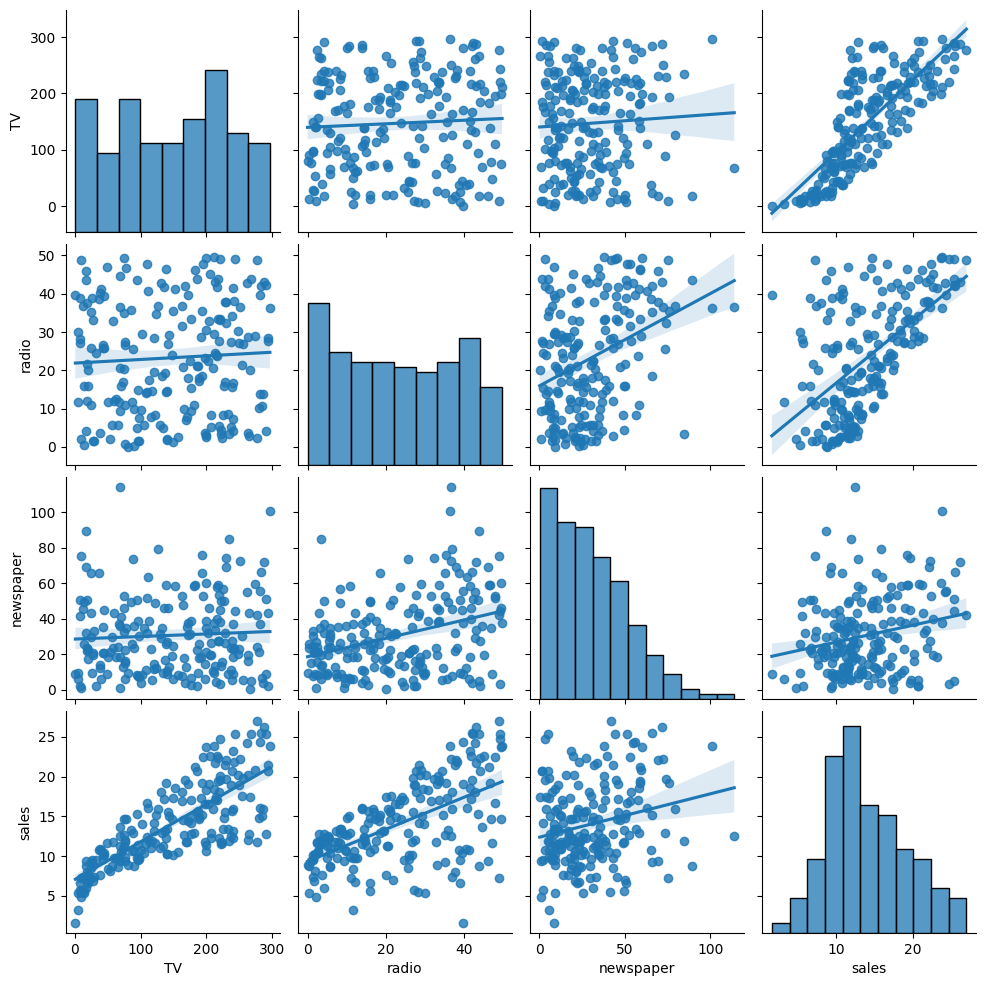

In [8]:
sns.pairplot(
    df_ads[["TV", "radio", "newspaper", "sales"]],
    kind="reg",       # agrega línea de regresión
    diag_kind="hist"  # histogramas en la diagonal
)
plt.show()

## Modelo con las tres variables

$$sales = \beta_0 + \beta_1 \cdot TV + \beta_2 \cdot radio + \beta_3 \cdot newspaper + \varepsilon$$

In [9]:
modelo_TV_radio_newspaper = smf.ols("sales ~ TV + radio + newspaper", data=df_ads).fit()
print(modelo_TV_radio_newspaper.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.58e-96
Time:                        06:30:38   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9389      0.312      9.422      0.0

El parámetro `newspaper` no es significativo. Incluso, desde el signo ya intuitivamente nos damos cuenta que algo extraño sucede y no sigue la lógica que pretendemos para el modelo. Veamos qué sucede cuando se analiza individualmente en una regresión simple.

### Regresión simple: newspaper

$$sales = \beta_0 + \beta_1 \cdot newspaper + \varepsilon$$

In [10]:
modelo_newspaper = smf.ols("sales ~ newspaper", data=df_ads).fit()
print(modelo_newspaper.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     10.89
Date:                Tue, 02 Jun 2026   Prob (F-statistic):            0.00115
Time:                        06:30:39   Log-Likelihood:                -608.34
No. Observations:                 200   AIC:                             1221.
Df Residuals:                     198   BIC:                             1227.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.3514      0.621     19.876      0.0

Ahora es significativo. Tanto el modelo como el parámetro.

Esto es un indicio de **multicolinealidad**: cuando `newspaper` está en el modelo junto a `TV` y `radio`, su efecto ya está capturado por las otras variables.

---

## Modelo TV + radio

$$sales = \beta_0 + \beta_1 \cdot TV + \beta_2 \cdot radio + \varepsilon$$

In [11]:
modelo_TV_radio = smf.ols("sales ~ TV + radio", data=df_ads).fit()
print(modelo_TV_radio.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           4.83e-98
Time:                        06:30:39   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9211      0.294      9.919      0.0

## Correlación parcial

La correlación parcial mide la relación entre una variable explicativa y la variable objetivo, una vez eliminado el efecto del resto de las variables del modelo.

$$r_{y,x_j \cdot X_{-j}}$$

En términos conceptuales:
$$\text{Correlación parcial} = \text{correlación entre los residuos de } y \text{ y } x_j$$

### Relación con el estadístico t

La correlación parcial puede expresarse a partir del estadístico $t$ del modelo como:

$$r_{y,x_j \cdot X_{-j}} = \frac{t_j}{\sqrt{t_j^2 + gl}}$$

donde:
- $t_j$ es el estadístico $t$ del coeficiente $\beta_j$
- $gl$ son los grados de libertad de los residuos del modelo

In [12]:
# Extraemos t-values y grados de libertad
t_vals  = modelo_TV_radio.tvalues
df_resid = modelo_TV_radio.df_resid

# Correlaciones parciales
r_parcial_TV    = t_vals["TV"]    / np.sqrt(t_vals["TV"]**2    + df_resid)
r_parcial_radio = t_vals["radio"] / np.sqrt(t_vals["radio"]**2 + df_resid)

print(f"Correlación parcial TV   : {r_parcial_TV:.4f}")
print(f"Correlación parcial radio: {r_parcial_radio:.4f}")

Correlación parcial TV   : 0.9198
Correlación parcial radio: 0.8574


El mejor ajuste parece ser el de ventas dependiendo de la publicidad en TV y radio.

---

## Gráfico de regresión parcial (Partial Regression Plot)

Primero eliminamos el efecto de TV tanto en `sales` como en `radio`. Luego analizamos la relación entre lo que queda.

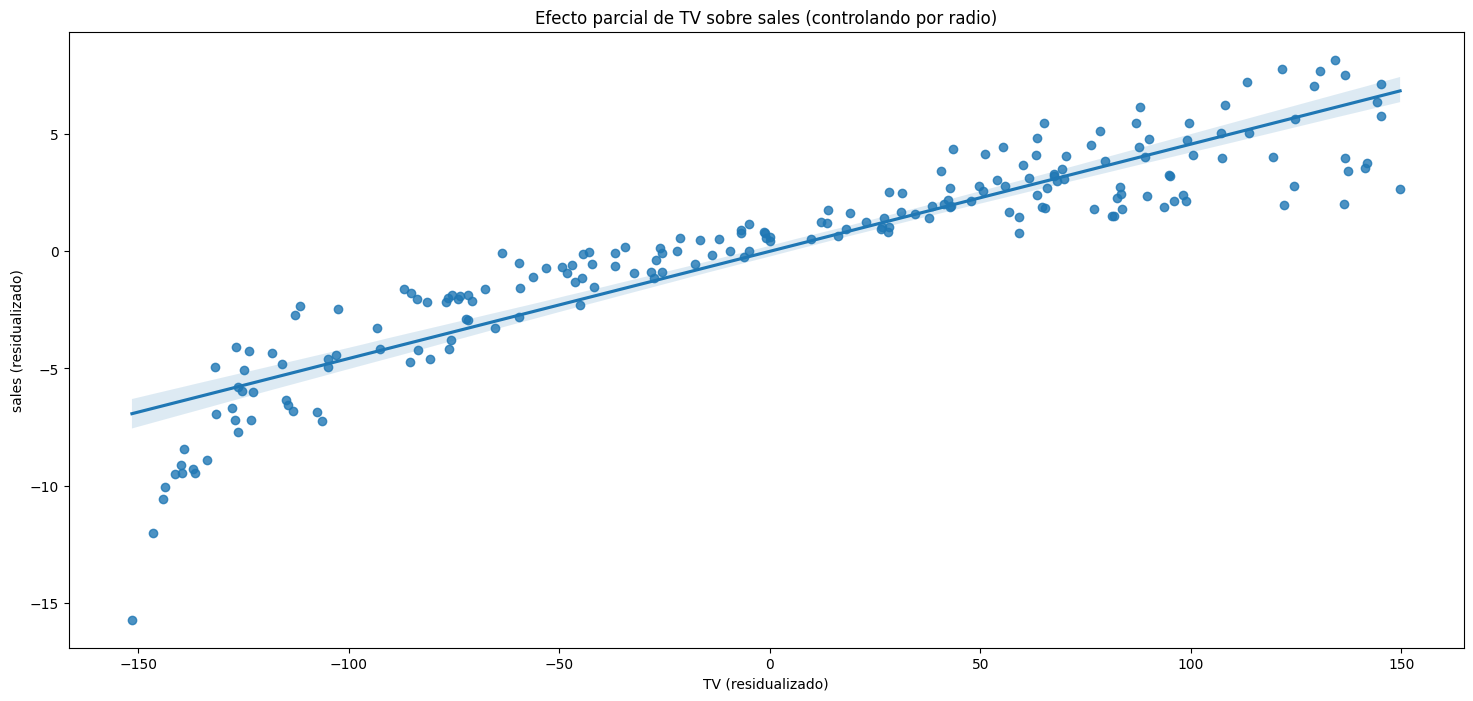

In [13]:
# Residuos de sales y TV, ambos controlando por radio
res_y = sm.OLS(df_ads["sales"], sm.add_constant(df_ads["radio"])).fit().resid
res_x = sm.OLS(df_ads["TV"],    sm.add_constant(df_ads["radio"])).fit().resid

plt.figure(figsize=(18, 8))
sns.regplot(x=res_x, y=res_y)
plt.xlabel("TV (residualizado)")
plt.ylabel("sales (residualizado)")
plt.title("Efecto parcial de TV sobre sales (controlando por radio)")
plt.show()

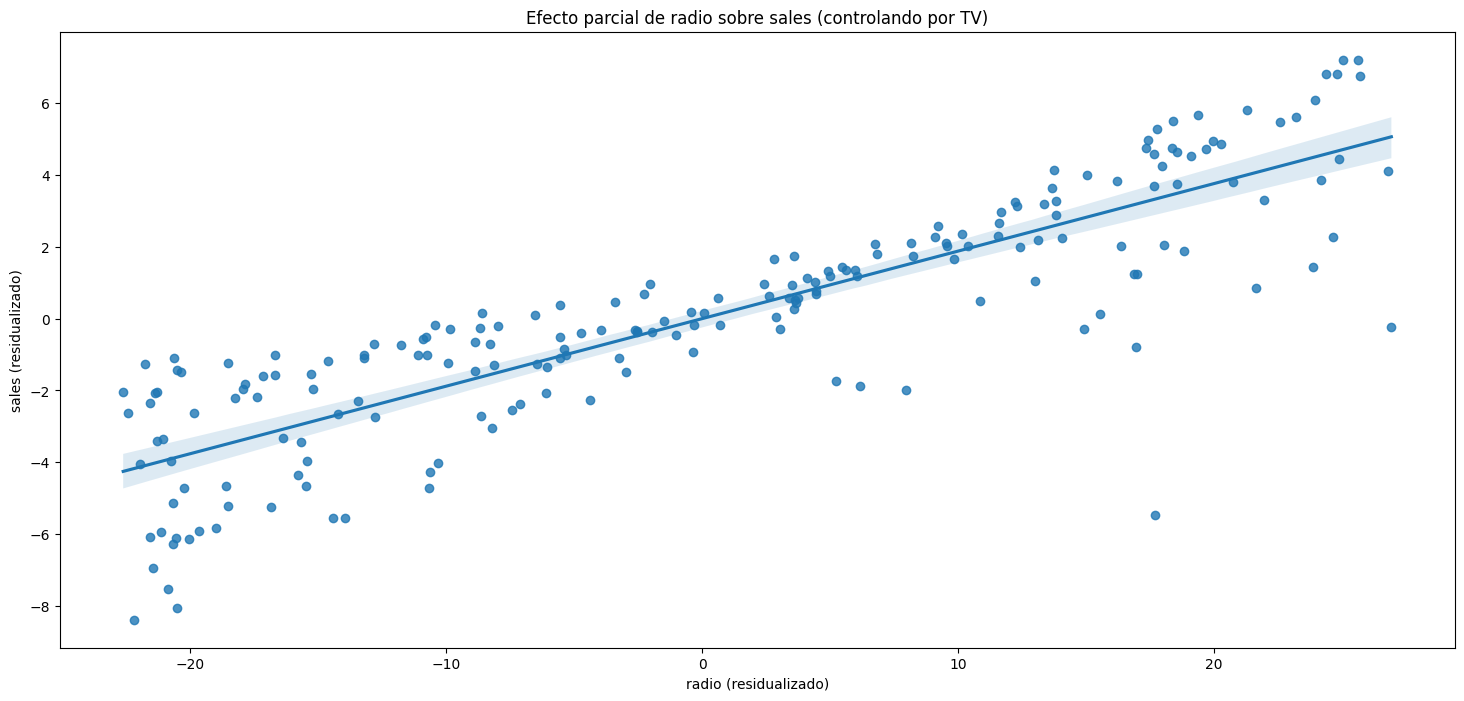

In [14]:
# Residuos de sales y radio, ambos controlando por TV
res_y = sm.OLS(df_ads["sales"], sm.add_constant(df_ads["TV"])).fit().resid
res_x = sm.OLS(df_ads["radio"], sm.add_constant(df_ads["TV"])).fit().resid

plt.figure(figsize=(18, 8))
sns.regplot(x=res_x, y=res_y)
plt.xlabel("radio (residualizado)")
plt.ylabel("sales (residualizado)")
plt.title("Efecto parcial de radio sobre sales (controlando por TV)")
plt.show()

## Visualización: relación observada vs modelo múltiple

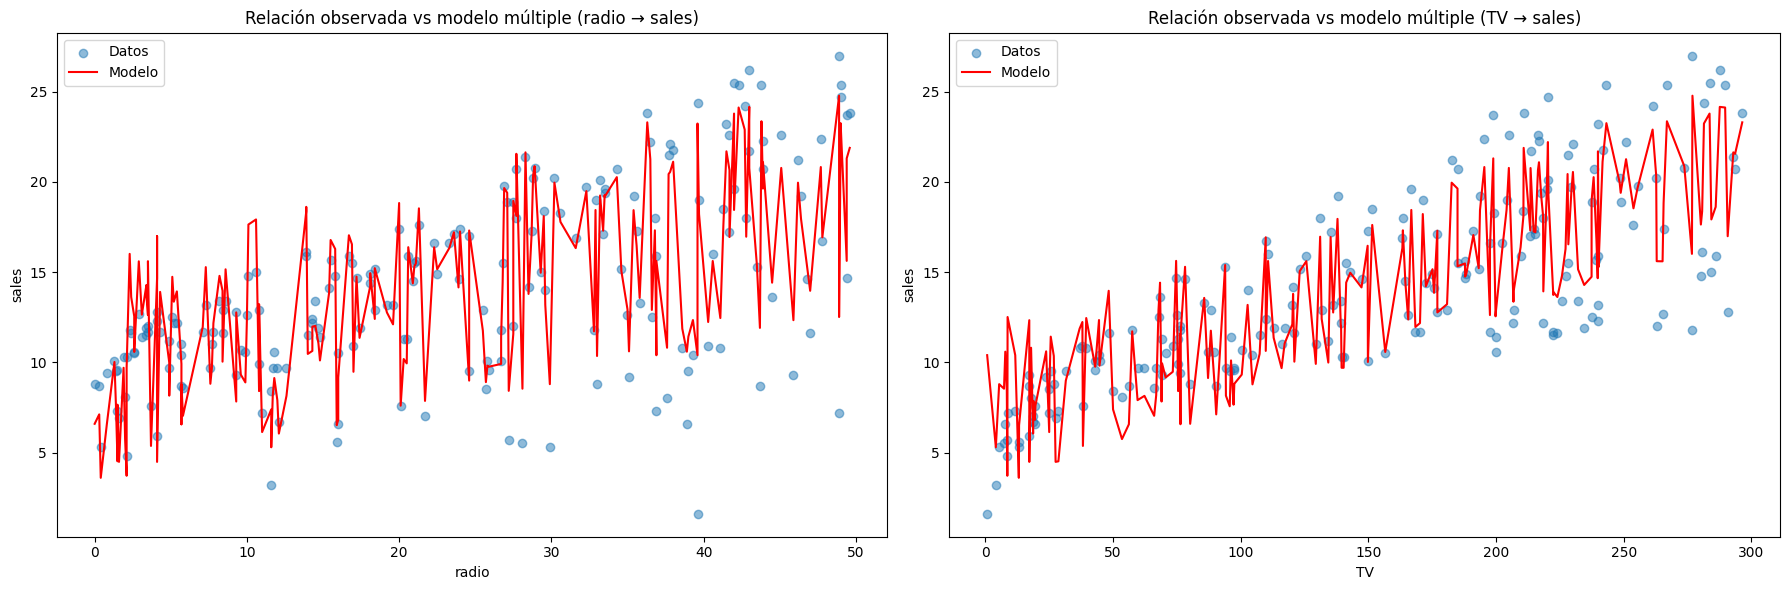

In [15]:
# Modelo múltiple
modelo = smf.ols("sales ~ TV + radio", data=df_ads).fit()
df_ads["pred"] = modelo.predict(df_ads)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Radio → sales
df_sorted = df_ads.sort_values("radio")
axes[0].scatter(df_ads["radio"], df_ads["sales"], alpha=0.5, label="Datos")
axes[0].plot(df_sorted["radio"], df_sorted["pred"], color="red", label="Modelo")
axes[0].set_title("Relación observada vs modelo múltiple (radio → sales)")
axes[0].set_xlabel("radio")
axes[0].set_ylabel("sales")
axes[0].legend()

# TV → sales
df_sorted = df_ads.sort_values("TV")
axes[1].scatter(df_ads["TV"], df_ads["sales"], alpha=0.5, label="Datos")
axes[1].plot(df_sorted["TV"], df_sorted["pred"], color="red", label="Modelo")
axes[1].set_title("Relación observada vs modelo múltiple (TV → sales)")
axes[1].set_xlabel("TV")
axes[1].set_ylabel("sales")
axes[1].legend()

plt.tight_layout()
plt.show()

---

## Diabetes

Este dataset tiene una serie de parámetros médicos que buscan predecir el avance de la enfermedad.

### Dataset Diabetes — Descripción de Variables

**Variable dependiente:**
- `target`: progresión de la enfermedad un año después → $Y = \text{progresión de la diabetes}$

**Variables explicativas:**

| Variable | Descripción |
|---|---|
| `age` | edad del paciente |
| `sex_bin` | sexo (binarizado) |
| `bmi` | índice de masa corporal |
| `bp` | presión arterial media |
| `s1` | colesterol total |
| `s2` | lipoproteínas de baja densidad (LDL) |
| `s3` | lipoproteínas de alta densidad (HDL) |
| `s4` | relación colesterol total / HDL |
| `s5` | log de triglicéridos |
| `s6` | glucosa en sangre |

In [34]:
from sklearn.datasets import load_diabetes

data = load_diabetes(as_frame=True)
df_diabetes = data.frame
df_diabetes["sex_bin"] = (df_diabetes["sex"] > 0).astype(int)  # normalizada → binomial
df_diabetes.drop(columns=["sex"], inplace=True)

In [35]:
df_diabetes.head()

,age,bmi,bp,s1,s2,s3,s4,s5,s6,target,sex_bin
0,0.038076,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0,1
1,-0.001882,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0,0
2,0.085299,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0,1
3,-0.089063,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0,0
4,0.005383,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0,0


In [36]:
df_diabetes.describe()

,age,bmi,bp,s1,s2,s3,s4,s5,s6,target,sex_bin
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000,442.000000
mean,-2.511817e-19,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484,0.468326
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005,0.499561
min,-1.072256e-01,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000,0.000000
25%,-3.729927e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000,0.000000
50%,5.383060e-03,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000,0.000000
75%,3.807591e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000,1.000000
max,1.107267e-01,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000,1.000000


Se observa una fuerte correlación entre `s1` y `s2`. Observemos la multicolinealidad.

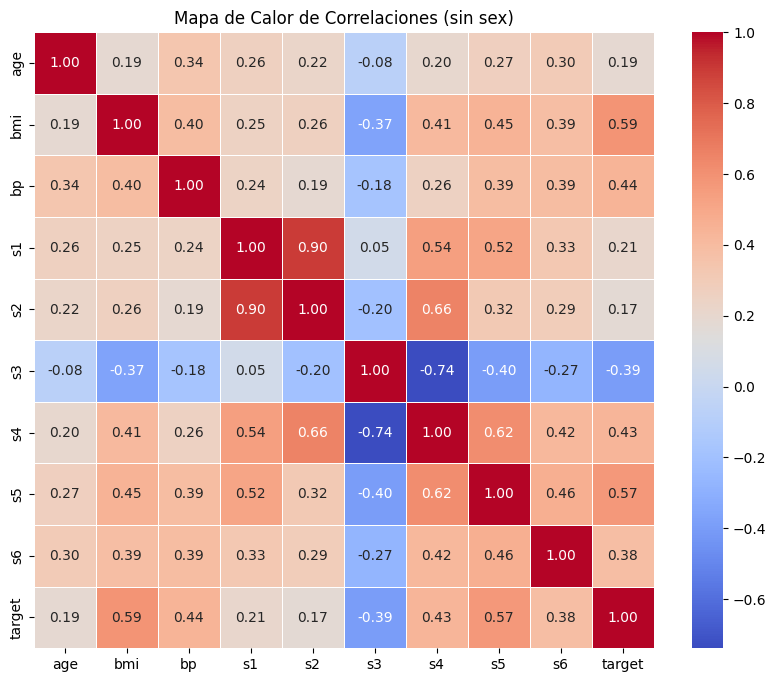

In [19]:
corr_df = df_diabetes.drop(columns=["sex_bin"]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5
)
plt.title("Mapa de Calor de Correlaciones (sin sex)")
plt.show()

También con `s3` y `s4`.

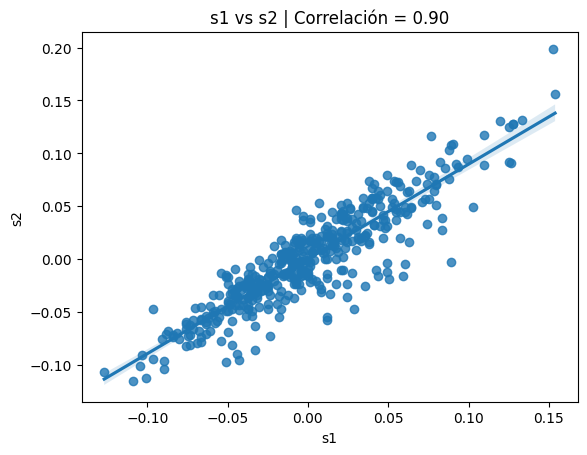

In [20]:
corr = df_diabetes["s1"].corr(df_diabetes["s2"])
sns.regplot(data=df_diabetes, x="s1", y="s2")
plt.title(f"s1 vs s2 | Correlación = {corr:.2f}")
plt.xlabel("s1")
plt.ylabel("s2")
plt.show()

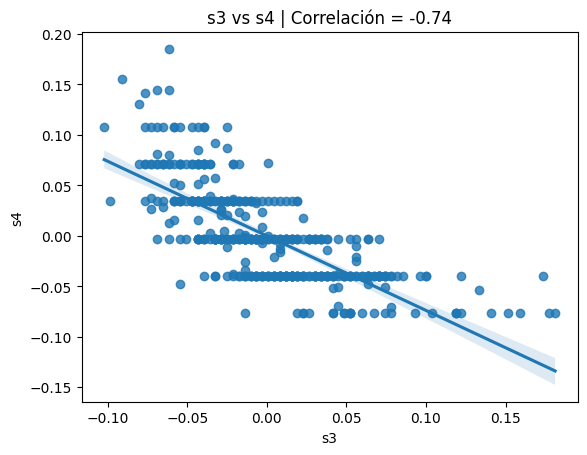

In [21]:
corr = df_diabetes["s3"].corr(df_diabetes["s4"])
sns.regplot(data=df_diabetes, x="s3", y="s4")
plt.title(f"s3 vs s4 | Correlación = {corr:.2f}")
plt.xlabel("s3")
plt.ylabel("s4")
plt.show()

La relación es claramente negativa, pero además vemos bandas porque `s4` no varía de forma continua en la práctica. Esto sugiere que ambas variables están capturando información muy similar.

---

## Pairplot de variables relevantes

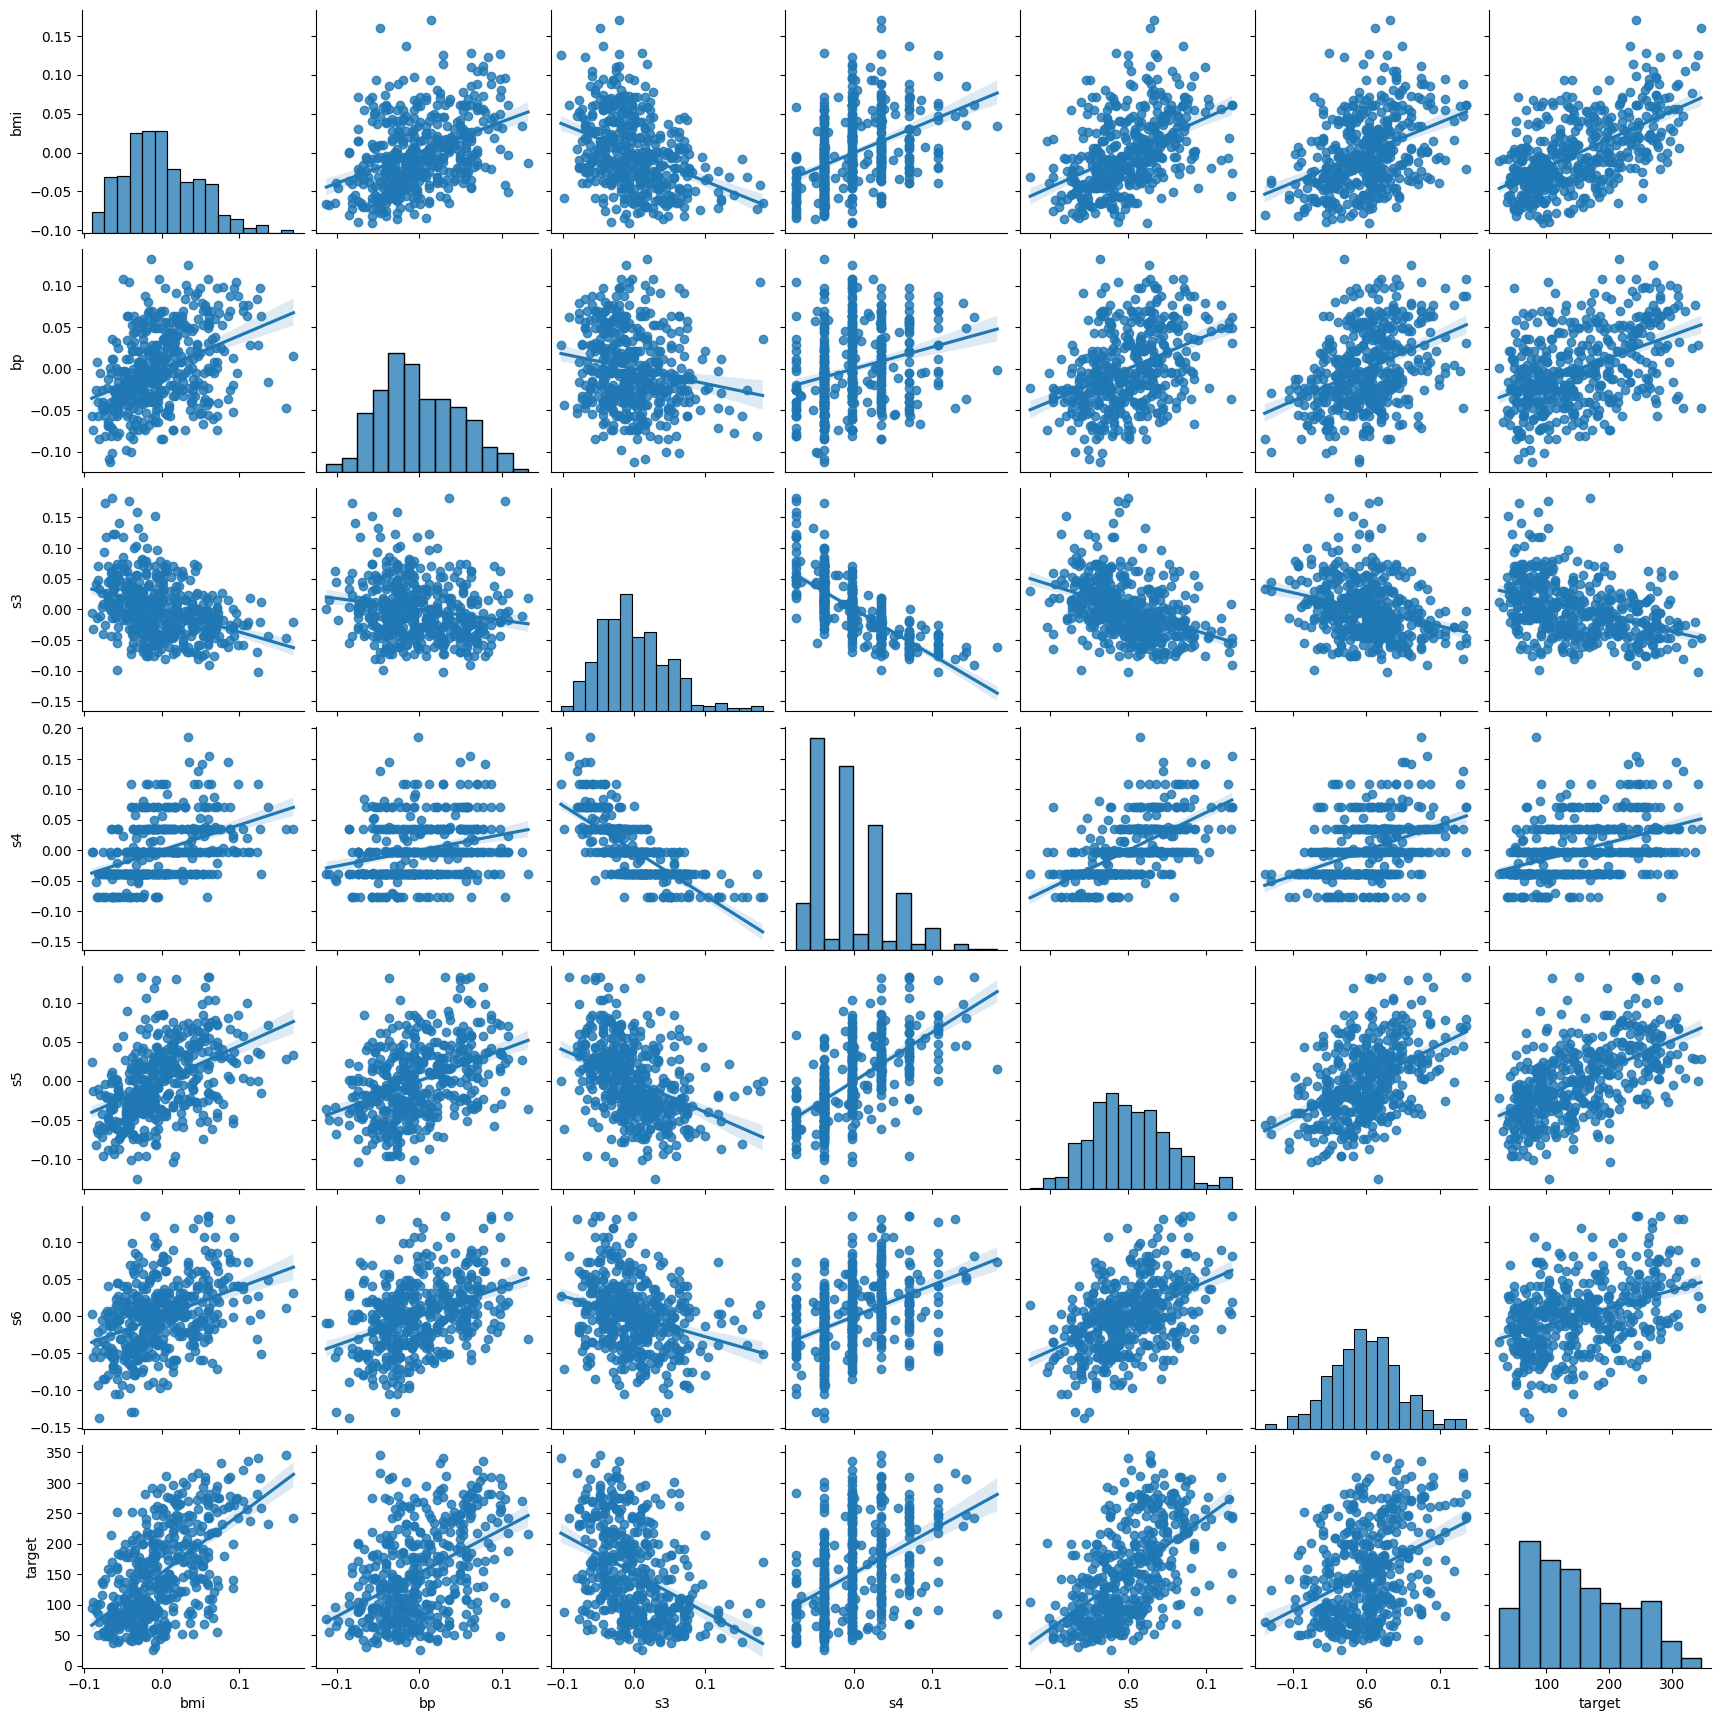

In [22]:
sns.pairplot(
    df_diabetes[["bmi", "bp", "s3", "s4", "s5", "s6", "target"]],
    kind="reg",
    diag_kind="hist"
)
plt.show()

## Ajuste progresivo del modelo

### Modelo completo (todas las variables)

In [23]:
modelo_diabetes = smf.ols(
    "target ~ age + bmi + bp + s1 + s2 + s3 + s4 + s5 + s6",
    data=df_diabetes
).fit()
print(modelo_diabetes.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.490
Method:                 Least Squares   F-statistic:                     48.11
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           8.80e-60
Time:                        06:31:12   Log-Likelihood:                -2393.7
No. Observations:                 442   AIC:                             4807.
Df Residuals:                     432   BIC:                             4848.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    152.1335      2.618     58.105      0.0

Dejamos aquellas variables que estaban más correlacionadas con el objetivo.

### Modelo reducido (variables con mayor correlación con target)

In [24]:
modelo_diabetes = smf.ols(
    "target ~ bmi + bp + s3 + s4 + s5 + s6",
    data=df_diabetes
).fit()
print(modelo_diabetes.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     70.88
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           2.28e-61
Time:                        06:31:12   Log-Likelihood:                -2396.5
No. Observations:                 442   AIC:                             4807.
Df Residuals:                     435   BIC:                             4836.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    152.1335      2.625     57.946      0.0

Quedémonos con las variables que mayor relación tenían con `target` (correlación > 0.50).

### Modelo con correlación > 0.50

In [25]:
modelo_diabetes = smf.ols(
    "target ~ bmi + s5",
    data=df_diabetes
).fit()
print(modelo_diabetes.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.457
Method:                 Least Squares   F-statistic:                     186.6
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           2.25e-59
Time:                        06:31:12   Log-Likelihood:                -2411.2
No. Observations:                 442   AIC:                             4828.
Df Residuals:                     439   BIC:                             4841.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    152.1335      2.702     56.303      0.0

Dejamos solo aquellas que tenían un coeficiente significativo.

### Modelo final (coeficientes significativos)

In [26]:
modelo_diabetes = smf.ols(
    "target ~ bmi + bp + s3 + s5",
    data=df_diabetes
).fit()
print(modelo_diabetes.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     105.6
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           7.24e-63
Time:                        06:31:12   Log-Likelihood:                -2397.7
No. Observations:                 442   AIC:                             4805.
Df Residuals:                     437   BIC:                             4826.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    152.1335      2.627     57.916      0.0

## Correlaciones parciales del modelo final

In [27]:
# Extraemos t-values y grados de libertad
t_vals   = modelo_diabetes.tvalues
df_resid = modelo_diabetes.df_resid

# Correlaciones parciales
r_parcial_bmi = t_vals["bmi"] / np.sqrt(t_vals["bmi"]**2 + df_resid)
r_parcial_bp  = t_vals["bp"]  / np.sqrt(t_vals["bp"]**2  + df_resid)
r_parcial_s3  = t_vals["s3"]  / np.sqrt(t_vals["s3"]**2  + df_resid)
r_parcial_s5  = t_vals["s5"]  / np.sqrt(t_vals["s5"]**2  + df_resid)

print(f"Correlación parcial bmi: {r_parcial_bmi:.4f}")
print(f"Correlación parcial bp : {r_parcial_bp:.4f}")
print(f"Correlación parcial s3 : {r_parcial_s3:.4f}")
print(f"Correlación parcial s5 : {r_parcial_s5:.4f}")

Correlación parcial bmi: 0.3742
Correlación parcial bp : 0.2025
Correlación parcial s3 : -0.1482
Correlación parcial s5 : 0.3286


## Gráfico de regresión parcial — BMI

El gráfico muestra la relación entre $bmi$ y $target$, controlando por el resto de las variables del modelo ($bp, s3, s5$).

- **Eje X** → parte de $bmi$ que no se explica por las otras variables (residuos de $bmi \sim bp + s3 + s5$)
- **Eje Y** → parte de $target$ que tampoco se explica por esas mismas variables (residuos de $target \sim bp + s3 + s5$)
- **Línea** → coeficiente de $bmi$ en el modelo múltiple

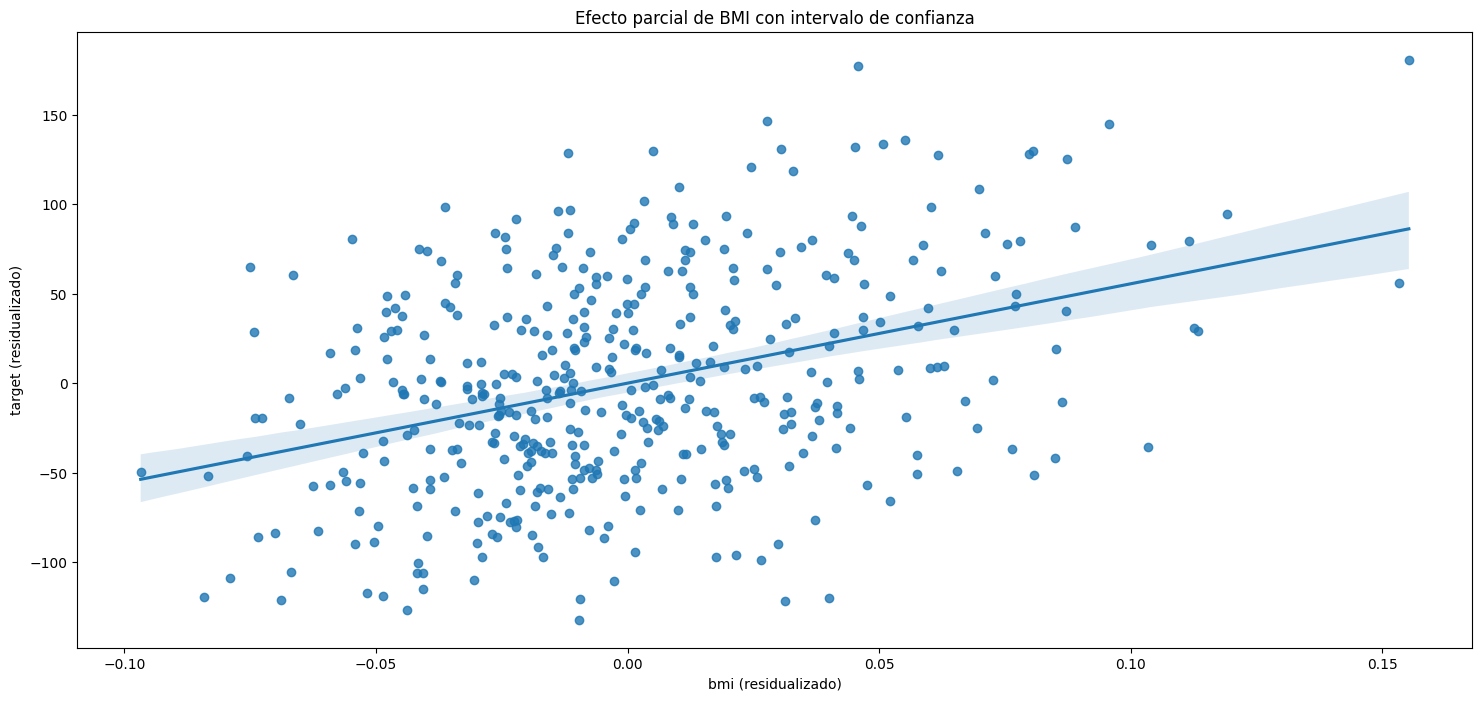

In [28]:
# Partial regression plot de BMI
otras = df_diabetes[["bp", "s3", "s5"]]

res_y = sm.OLS(df_diabetes["target"], sm.add_constant(otras)).fit().resid
res_x = sm.OLS(df_diabetes["bmi"],    sm.add_constant(otras)).fit().resid

plt.figure(figsize=(18, 8))
sns.regplot(x=res_x, y=res_y)
plt.xlabel("bmi (residualizado)")
plt.ylabel("target (residualizado)")
plt.title("Efecto parcial de BMI con intervalo de confianza")
plt.show()

## Predicción con intervalo de confianza

El gráfico muestra la relación entre $bmi$ y $target$, junto con las predicciones del modelo de regresión múltiple.

- Los puntos representan los valores **observados**.
- La línea roja representa los valores **predichos** por el modelo:
$$\widehat{target} = \beta_0 + \beta_1 \cdot bmi + \beta_2 \cdot bp + \beta_3 \cdot s3 + \beta_4 \cdot s5$$
- La banda sombreada representa el **IC del 95%** sobre la media.

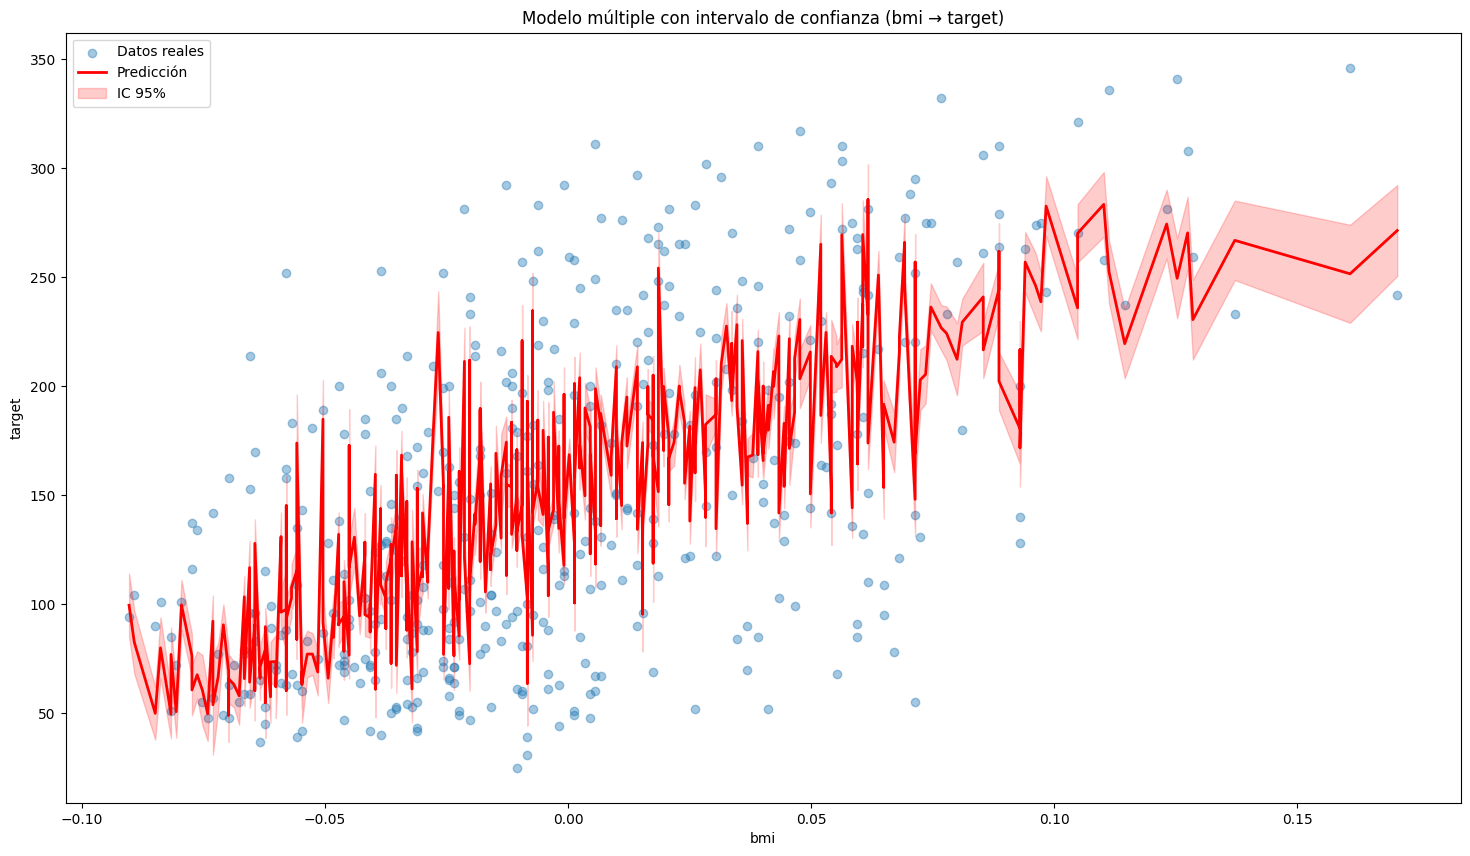

In [29]:
# Predicción con intervalo de confianza
pred = modelo_diabetes.get_prediction(df_diabetes)
pred_summary = pred.summary_frame(alpha=0.05)
df_diabetes["pred"]     = pred_summary["mean"]
df_diabetes["ci_lower"] = pred_summary["mean_ci_lower"]
df_diabetes["ci_upper"] = pred_summary["mean_ci_upper"]

plt.figure(figsize=(18, 10))
plt.scatter(df_diabetes["bmi"], df_diabetes["target"], alpha=0.4, label="Datos reales")

df_sorted = df_diabetes.sort_values("bmi")
plt.plot(df_sorted["bmi"], df_sorted["pred"], color="red", lw=2, label="Predicción")
plt.fill_between(
    df_sorted["bmi"],
    df_sorted["ci_lower"],
    df_sorted["ci_upper"],
    color="red",
    alpha=0.2,
    label="IC 95%"
)

plt.xlabel("bmi")
plt.ylabel("target")
plt.title("Modelo múltiple con intervalo de confianza (bmi → target)")
plt.legend()
plt.show()